In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import chemcoord as cc

from flonacomldft.utils.silver_isomers_utils import get_construction_table
from flonacomldft.utils.io_utils import load_csv_file, get_path
from ase.io.trajectory import Trajectory

from flonacomldft.internal_coordinates import Coordinates_mapping

In [3]:
is0_traj = Trajectory(get_path() + 'md_trajectories/ag6_is0_lcao.traj')
coord_mapping = Coordinates_mapping()
ag6  = is0_traj[0]

In [4]:
xyz = coord_mapping._get_xyz_from_molecule(ag6)
xyz

,atom,x,y,z
0,Ag,8.000809,5.656600,8.0
1,Ag,7.983858,10.343400,8.0
2,Ag,6.601959,8.059975,8.0
3,Ag,5.330772,5.712291,8.0
4,Ag,9.386290,8.069162,8.0
5,Ag,10.669228,5.726007,8.0


In [5]:
zmat_matrix = coord_mapping._get_zmat_matrix_from_xyz(xyz)
zmat_matrix

,atom,b,bond,a,angle,d,dihedral
0,Ag,$\vec{0}$,12.649509,$\vec{e_z}$,50.769952,$\vec{e_x}$,35.260447
2,Ag,0,2.780825,$\vec{e_z}$,94.115069,$\vec{e_x}$,-111.190557
3,Ag,2,2.669744,0,58.634900,$\vec{e_x}$,-41.964342
4,Ag,2,2.784346,3,118.623015,0,-0.000000
5,Ag,4,2.671386,2,118.512795,3,-0.000000
1,Ag,4,2.671886,2,58.528560,3,-180.000000


In [6]:
zmat = coord_mapping._get_zmat_from_xyz(xyz)
zmat

array([ 2.78082505,  2.66974442,  2.78434571,  2.67138608,  2.67188589,
        1.02337206,  2.07036218,  2.06843848,  1.02151607,  0.        ,
        0.        , -3.14159265])

In [7]:
coord_mapping._build_zmat_matrix_from_zmat(zmat)

,atom,b,bond,a,angle,d,dihedral
0,Ag,$\vec{0}$,1.270000,$\vec{e_z}$,127.000106,$\vec{e_x}$,127.000106
2,Ag,0,2.780825,$\vec{e_z}$,127.000106,$\vec{e_x}$,127.000106
3,Ag,2,2.669744,0,58.634900,$\vec{e_x}$,127.000106
4,Ag,2,2.784346,3,118.623015,0,0.000000
5,Ag,4,2.671386,2,118.512795,3,0.000000
1,Ag,4,2.671886,2,58.528560,3,-180.000000


In [8]:
zmat_matrix = coord_mapping._get_zmat_matrix_from_molecule(ag6)
zmat_matrix

,atom,b,bond,a,angle,d,dihedral
0,Ag,$\vec{0}$,12.649509,$\vec{e_z}$,50.769952,$\vec{e_x}$,35.260447
2,Ag,0,2.780825,$\vec{e_z}$,94.115069,$\vec{e_x}$,-111.190557
3,Ag,2,2.669744,0,58.634900,$\vec{e_x}$,-41.964342
4,Ag,2,2.784346,3,118.623015,0,-0.000000
5,Ag,4,2.671386,2,118.512795,3,-0.000000
1,Ag,4,2.671886,2,58.528560,3,-180.000000


In [9]:
coord_mapping._build_oriented_and_centered_molecule(ag6)

,atom,x,y,z
0,Ag,-0.610402,0.810027,-0.764307
2,Ag,-1.774534,3.306480,-1.145761
3,Ag,-3.104182,1.320330,0.043684
4,Ag,0.830028,2.837484,-2.011138
5,Ag,1.889367,0.417454,-1.614201
1,Ag,-0.345199,5.213307,-2.347710


<AxesSubplot:>

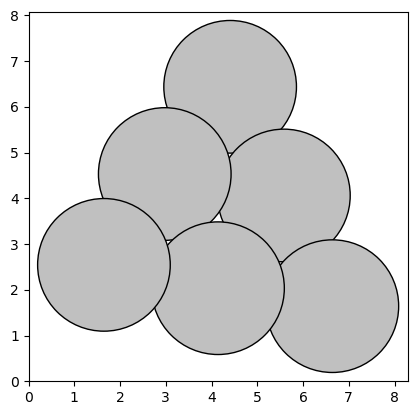

In [10]:
from ase.visualize.plot import plot_atoms
ag6_centered = coord_mapping.get_oriented_and_centered_molecule(ag6)
plot_atoms(ag6_centered)


In [11]:
coord_mapping.get_logdetjac_internal_to_cartesian(zmat)

(-1.0, 9.439842463071729)

In [13]:
coord_mapping.get_logdetjac_cartesian_to_internal(ag6, True)

(-1.0, -9.439842463071733)

In [ ]:
cc.Cartesian.from_ase_atoms(ag6) # get xyz Cartesian chemcoord object
cc.Cartesian.get_ase_atoms(xyz) # get ase Atoms (molecule) object
# get Zmat chemcoord object from ase Atoms (molecule)
cc.Cartesian.from_ase_atoms(ag6).get_zmat(construction_table=get_construction_table())
# get Cartesian chemcoord object from Zmat object
cc.Cartesian.from_ase_atoms(ag6).get_zmat(construction_table=get_construction_table()).get_cartesian()

In [ ]:
cc.Cartesian.from_ase_atoms(ag6).get_zmat(construction_table=get_construction_table()).get_grad_cartesian()

In [ ]:
cc.Cartesian.from_ase_atoms(ag6).get_zmat(construction_table=get_construction_table()).get_cartesian().get_grad_zmat(get_construction_table())

In [ ]:
xyz.get_grad_zmat(get_construction_table())